# Step 2: Basic Flyby

## Purpose
固定された1天体のまわりを宇宙機が通過するとき、
入射角を変えることで最終進行方向がどのように変わるかを調べる。

In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# ----------------------------
# Parameters
# ----------------------------
mu = 1.0
dt = 0.001
steps = 20000

# ----------------------------
# Simulation
# ----------------------------
def simulate_basic_flyby(mu, x, y, vx, vy, dt, steps):
    x_list = []
    y_list = []
    vx_list = []
    vy_list = []
    v_list = []
    r_list = []

    for _ in range(steps):
        r = np.sqrt(x**2 + y**2)

        ax = -mu * x / r**3
        ay = -mu * y / r**3

        vx += ax * dt
        vy += ay * dt

        x += vx * dt
        y += vy * dt

        v = np.sqrt(vx**2 + vy**2)
        r_new = np.sqrt(x**2 + y**2)

        x_list.append(x)
        y_list.append(y)
        vx_list.append(vx)
        vy_list.append(vy)
        v_list.append(v)
        r_list.append(r_new)

    return x_list, y_list, vx_list, vy_list, v_list, r_list

In [21]:
# ----------------------------
# Fixed initial condition
# ----------------------------
x0 = -4.0
y0 = -4.0
v0 = 0.5

In [22]:
def velocity_from_angle(v0, angle_deg):
    theta = np.radians(angle_deg)
    vx0 = v0 * np.cos(theta)
    vy0 = v0 * np.sin(theta)
    return vx0, vy0

In [23]:
angle_deg = 0
vx0, vy0 = velocity_from_angle(v0, angle_deg)

x_list, y_list, vx_list, vy_list, v_list, r_list = simulate_basic_flyby(
    mu, x0, y0, vx0, vy0, dt, steps
)

initial angle = 0 deg
final angle = 131.39335513577666


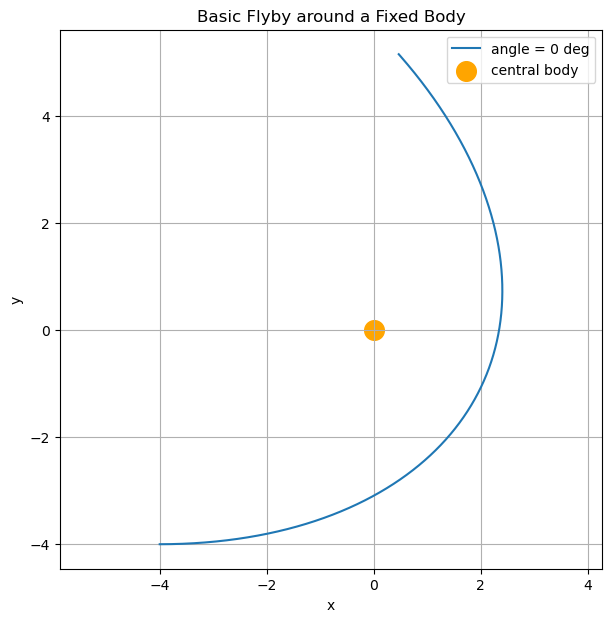

In [24]:
print("initial angle =", angle_deg, "deg")
print("final angle =", np.degrees(np.arctan2(vy_list[-1], vx_list[-1])))
plt.figure(figsize=(7, 7))
plt.plot(x_list, y_list, label=f"angle = {angle_deg} deg")
plt.scatter(0, 0, s=200, color="orange", label="central body")
plt.axis("equal")
plt.grid()
plt.legend()
plt.title("Basic Flyby around a Fixed Body")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

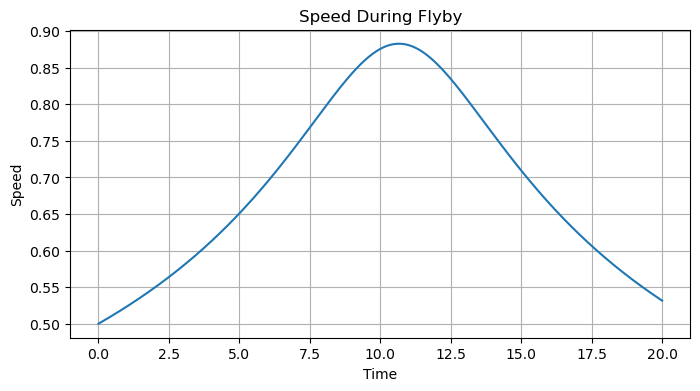

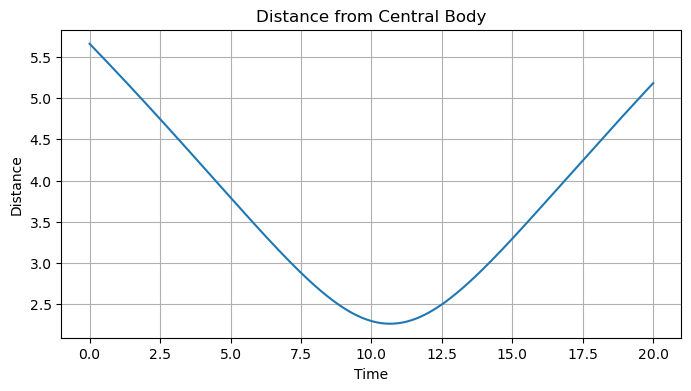

In [25]:
time = np.arange(len(v_list)) * dt

plt.figure(figsize=(8, 4))
plt.plot(time, v_list)
plt.grid()
plt.title("Speed During Flyby")
plt.xlabel("Time")
plt.ylabel("Speed")
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(time, r_list)
plt.grid()
plt.title("Distance from Central Body")
plt.xlabel("Time")
plt.ylabel("Distance")
plt.show()

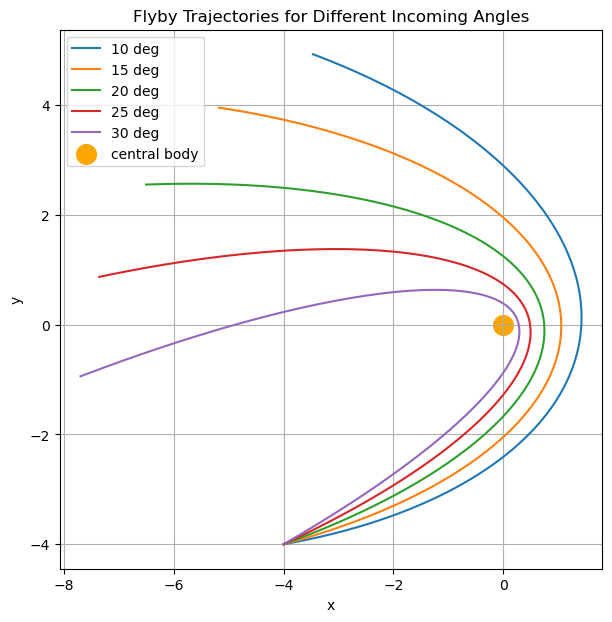

In [27]:
angles_deg = [10, 15, 20, 25, 30]

plt.figure(figsize=(7, 7))

for angle_deg in angles_deg:
    vx0, vy0 = velocity_from_angle(v0, angle_deg)

    x_list, y_list, vx_list, vy_list, v_list, r_list = simulate_basic_flyby(
        mu, x0, y0, vx0, vy0, dt, steps
    )

    plt.plot(x_list, y_list, label=f"{angle_deg} deg")

plt.scatter(0, 0, s=200, color="orange", label="central body")
plt.axis("equal")
plt.grid()
plt.legend()
plt.title("Flyby Trajectories for Different Incoming Angles")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [28]:
angles_deg = [10, 15, 20, 25, 30]

print("incoming angle -> final direction")
print("-" * 35)

for angle_deg in angles_deg:
    vx0, vy0 = velocity_from_angle(v0, angle_deg)

    x_list, y_list, vx_list, vy_list, v_list, r_list = simulate_basic_flyby(
        mu, x0, y0, vx0, vy0, dt, steps
    )

    final_angle_deg = np.degrees(np.arctan2(vy_list[-1], vx_list[-1]))
    print(f"{angle_deg:>6.1f} deg -> {final_angle_deg:>8.2f} deg")

incoming angle -> final direction
-----------------------------------
  10.0 deg ->   159.42 deg
  15.0 deg ->   171.41 deg
  20.0 deg ->  -177.82 deg
  25.0 deg ->  -168.07 deg
  30.0 deg ->  -159.13 deg
